# Oefeningen

## Breast Cancer

In [2]:
import numpy as np
import pandas as pd
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report

In [3]:
# Laad de dataset in. Bekijk deze even om te zien waar je juist mee gaan werken
data = load_breast_cancer()
print(data.DESCR)
X = data.data
y = data.target

.. _breast_cancer_dataset:

Breast cancer Wisconsin (diagnostic) dataset
--------------------------------------------

**Data Set Characteristics:**

:Number of Instances: 569

:Number of Attributes: 30 numeric, predictive attributes and the class

:Attribute Information:
    - radius (mean of distances from center to points on the perimeter)
    - texture (standard deviation of gray-scale values)
    - perimeter
    - area
    - smoothness (local variation in radius lengths)
    - compactness (perimeter^2 / area - 1.0)
    - concavity (severity of concave portions of the contour)
    - concave points (number of concave portions of the contour)
    - symmetry
    - fractal dimension ("coastline approximation" - 1)

    The mean, standard error, and "worst" or largest (mean of the three
    worst/largest values) of these features were computed for each image,
    resulting in 30 features.  For instance, field 0 is Mean Radius, field
    10 is Radius SE, field 20 is Worst Radius.

    - 

In [4]:
print("X shape:", X.shape)
print("y shape:", y.shape)
print("Classes:", data.target_names)

X shape: (569, 30)
y shape: (569,)
Classes: ['malignant' 'benign']


In [8]:
# Split de dataset. We gebruiken in deze les consequent random seed 10.
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    random_state=10,
    test_size=.2
)

In [9]:
# Gebruik een standardscaler
scaler = StandardScaler()

scaler.fit(X_train)

X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

In [12]:
# Creëer en train een SVM classifier. Gebruik random seed 10.
svc = SVC(random_state=10)

svc.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo random number generation for shuffling the data forprobability estimates. Ignored when `probability` is False.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",10
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide <shrinking_svm>`.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide <scores_probabilities>`...deprecated:: 1.9 The `probability` parameter is deprecated and will be removed in 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`.",'deprecated'
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None


In [13]:
# Maak voorspellingen over de test data
y_pred = svc.predict(X_test)

In [14]:
# Bereken de accuraatheidscore van je model
accuracy_score(y_test, y_pred)

# Laat een classification report genereren.
classification_report(y_test, y_pred)


'              precision    recall  f1-score   support\n\n           0       0.93      1.00      0.96        39\n           1       1.00      0.96      0.98        75\n\n    accuracy                           0.97       114\n   macro avg       0.96      0.98      0.97       114\nweighted avg       0.98      0.97      0.97       114\n'

Even opfrissen:
- *Precision*: (aantal True Positives) / (aantal True Positives + aantal False Positives)
- *Recall*: (aantal True Positives) / (aantal True Positives + aantal False Negatives)
- *Accuracy*: (aantal True Positive + aantal True Negative) / (totaal aantal Positive + totaal aantal Negative)

In [15]:
# Extra oefening: je kan nog finetunen met de hyperparameters...
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import GridSearchCV

X_train_raw, X_test_raw, y_train_raw, y_test_raw = train_test_split(
    X,
    y,
    random_state=10,
    test_size=.25
)

pipeline = make_pipeline(
    StandardScaler(),
    SVC(random_state=10)
)

param_grid = {
    "svc__C": [.1, 1, 10, 50, 100],
    "svc__kernel": ["linear", "rbf"]
}

grid_search = GridSearchCV(
    pipeline,
    param_grid,
    cv=5,
    scoring="accuracy"
)

grid_search.fit(X_train_raw, y_train_raw)

print("Best parameters:", grid_search.best_params_)
print("Best average CV accuracy:", grid_search.best_score_)

Best parameters: {'svc__C': 0.1, 'svc__kernel': 'linear'}
Best average CV accuracy: 0.9788235294117648


## Digits

Experimenteer met verschillende kernels, C-waardes, en kies een optimale configuratie.

In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report
from sklearn.pipeline import Pipeline


In [23]:
# Digits dataset:
digits = datasets.load_digits()

# laad de data in goede variabelen
X = digits.data
y = digits.target

In [24]:
# Data splitten
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    random_state=10,
    test_size=.25
)

In [26]:
# Standardizeren, doe dit eens in een pipeline samen met je model
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("SVC", SVC(random_state=10))
])

pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scaler', ...), ('SVC', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](10,)","[0,1,2,...,7,8,9]"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,64
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
Name,Type,Value


In [27]:
# Maak voorspellingen op de test data
y_pred = pipeline.predict(X_test)

In [28]:

# bereken accuraatheid en classificatie report. Welk cijfers is het moeilijkst om te classificeren ?
accuracy_score(y_test, y_pred)

classification_report(y_test, y_pred)

'              precision    recall  f1-score   support\n\n           0       1.00      1.00      1.00        46\n           1       0.96      0.98      0.97        44\n           2       0.98      1.00      0.99        45\n           3       1.00      0.96      0.98        48\n           4       0.93      0.95      0.94        40\n           5       1.00      1.00      1.00        41\n           6       0.98      0.98      0.98        47\n           7       1.00      0.98      0.99        47\n           8       0.93      0.98      0.95        43\n           9       1.00      0.96      0.98        49\n\n    accuracy                           0.98       450\n   macro avg       0.98      0.98      0.98       450\nweighted avg       0.98      0.98      0.98       450\n'

Voor de volgende opgave mag je de hulp van ChatGPT en dergelijke inroepen.

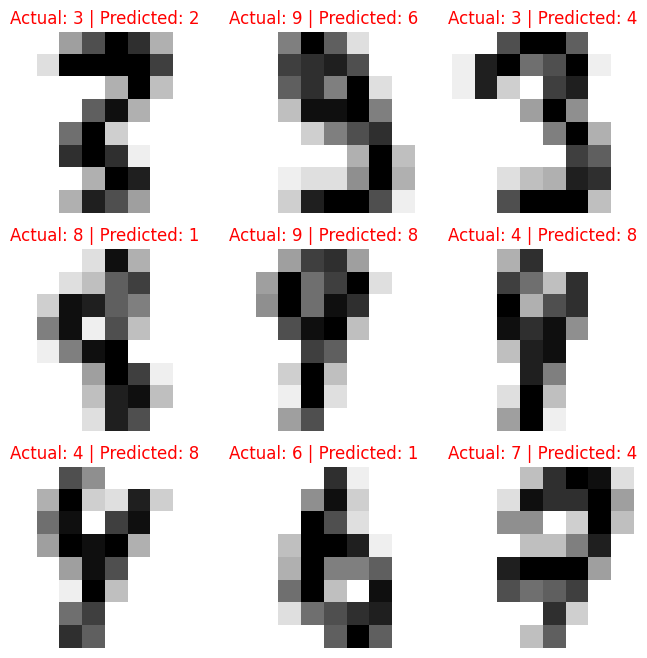

In [30]:
# Maak een plot van de eerste 9 testcases, waarbij je het echte label in de titel vergelijk met het voorspelde label.
# de bedoeling is dat je zo zelf visueel kan checken of de classifier het voor de specifieke items juist had.
# pas je code aan zodat er enkel testcases worden getoond die fout werden geclassificeerd.

# Select the first 9 test samples
indices = np.flatnonzero(y_test != y_pred)[:9]

fig, axes = plt.subplots(3, 3, figsize=(8, 8))

# Hide axes, including any unused panels
for ax in axes.ravel():
    ax.axis("off")

for ax, i in zip(axes.ravel(), indices):
    image = X_test[i].reshape(8, 8)

    ax.imshow(image, cmap="gray_r", vmin=0, vmax=16)
    ax.set_title(
        f"Actual: {y_test[i]} | Predicted: {y_pred[i]}",
        color="green" if y_test[i] == y_pred[i] else "red"
    )

## Wijn

Train een SVM-classificator op de Wine-dataset, die je kunt laden met 'sklearn.datasets.load_wine()'. Deze dataset bevat de chemische analyse van 178 wijnmonsters geproduceerd door 3 verschillende telers: het doel is om een classificatiemodel te trainen dat in staat is om de cultivator te voorspellen op basis van de chemische analyse van de wijn. Aangezien SVM-classifiers binaire classifiers zijn, moet je one-versus-all gebruiken om alle 3 klassen te classificeren. Welke nauwkeurigheid kan je bereiken?

Stappenplan:
1. Data inladen
2. Train/test split
3. Een lineaire SVM gebruiken
4. Een lineaire SVM gebruiken met 1000000 iteraties
5. Evalueren
6. Oplossingen zoeken voor mogelijke problemen

In [44]:
from sklearn.datasets import load_wine
from sklearn.svm import LinearSVC
# Lineaire SVM gebruiken
# Het probleem met meerdere klasses oplossen - bekijk de decoumentatie van LinearSVM op scikit learn docs
wine = load_wine()
X = wine.data
y = wine.target

lsvm = LinearSVC()

pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("linearsvm", LinearSVC(random_state=10, max_iter=1_000_000))
])

In [45]:
# gebruik 1000000 iteraties
# wat is nu je conclusie over de dataset ? Hoe kun je dit oplossen ?


X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=10
)

pipeline.fit(X_train, y_train)

y_pred = pipeline.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.9333333333333333
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        13
           1       1.00      0.87      0.93        23
           2       0.75      1.00      0.86         9

    accuracy                           0.93        45
   macro avg       0.92      0.96      0.93        45
weighted avg       0.95      0.93      0.94        45



In [48]:
# zoek op de documentatie op hoe je de cross_val_score kan gebruiken om cross-validatie te doen
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    pipeline,
    X_train,
    y_train,
    cv=5,
    scoring="accuracy"
)

### Nu kijken we naar andere kernels voor algemene SVM

We werken verder met dezelfde dataset, maar nu niet meer beperkt tot een lineaire SVM

In [49]:
from sklearn.pipeline import Pipeline, make_pipeline # ter illustratie, make_pipeline heeft lichtjes andersyntax dan met Pipeline werken
svm_clf = make_pipeline(StandardScaler(), SVC(random_state=10))
cross_val_score(svm_clf, X_train, y_train).mean()

0.9925925925925926

Nu gaan ze zoeken naar optimizatie van parameters. Dit moet ik ook nog introduceren in de theorieles

In [54]:
from sklearn.model_selection import GridSearchCV

# optimaliseer de parameters met CVGrid Search
param_grid = {
    "svc__C": [.1, 1, 10, 100],
    "svc__kernel": ["linear", "rbf", "poly"]
}

grid_search = GridSearchCV(
    svm_clf,
    param_grid,
    cv=5,
    scoring="accuracy"
)

grid_search.fit(X_train, y_train)

print("Best parameters:", grid_search.best_params_)
print("Best CV accuracy:", grid_search.best_score_)
print("Test accuracy:", grid_search.score(X_test, y_test))

Best parameters: {'svc__C': 10, 'svc__kernel': 'rbf'}
Best CV accuracy: 1.0
Test accuracy: 0.9333333333333333


Vergelijk nu de best_score_component van de CVGridSearch met de de score die dit model haalt op de test set. Er zit een verschil op. Wat is er gebeurt ? Hoe hadden we dit moeten oplossen ?

## Regressie met een SVM

Gegeven een dataset, kan je regressie doen in plaats van classificatie. De algoritmes werken bijna hetzelfde, met volgende cruciaal verschil:
- de classifier wil zoveel mogelijk instances *buiten* de straat zetten.
- de regressor wil zoveel mogelijk instances *binnen* de straat zetten.

Beschouw volgende dataset die je wil benaderen met een regressiemodel:

In [55]:
from sklearn.svm import SVR # de R in SVR is van regressor, de C in SVC van classifier
import numpy as np
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.preprocessing import StandardScaler

# code om een kwadratische dataset te genereren
np.random.seed(10)
X = 2 * np.random.rand(50, 1) - 1
y = 0.2 + 0.1 * X[:, 0] + 0.5 * X[:, 0] ** 2 + np.random.randn(50) / 10

In [ ]:
# maak een pipeline van een standaardscaler en de voor hand liggende SVR voor dit probleem.

svm_poly_reg = Pipeline([
    ("scaler", StandardScaler()),
    ("svr", SVR(kernel="poly", degree=2))
])

svm_poly_reg.fit(X, y)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scaler', ...), ('svr', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,1
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
Name,Type,Value
"mean_ mean_: ndarray of shape (n_features,) or NoneThe mean value for each feature in the training set.Equal to ``None`` when ``with_mean=False`` and ``with_std=False``.","ndarray[float64](1,)",[0.]


Dit stukje code kan je hergebruiken om afbeeldingen op te slaan:

In [57]:
from pathlib import Path
import matplotlib.pyplot as plt

IMAGES_PATH = Path() / "images" / "training_linear_models"
IMAGES_PATH.mkdir(parents=True, exist_ok=True)

def save_fig(fig_id, tight_layout=True, fig_extension="png", resolution=300):
    path = IMAGES_PATH / f"{fig_id}.{fig_extension}"
    if tight_layout:
        plt.tight_layout()
    plt.savefig(path, format=fig_extension, dpi=resolution)

Met volgende code kun je bekijken wat het model heeft bereikt (ter illustratie)

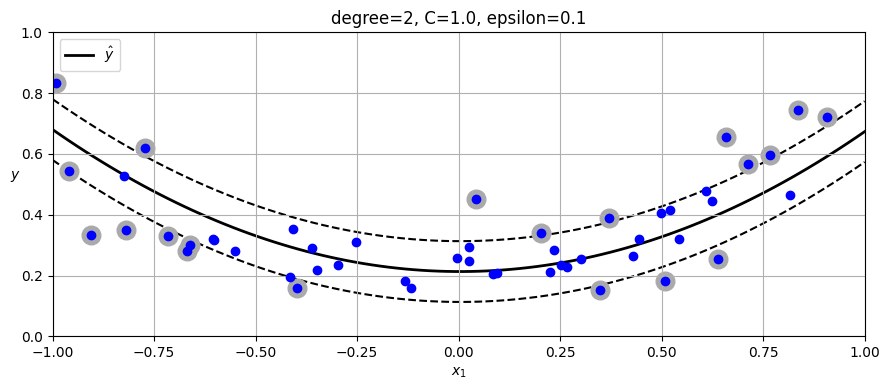

In [58]:

import matplotlib.pyplot as plt

def find_support_vectors(svm_reg, X, y):
    y_pred = svm_reg.predict(X)
    epsilon = svm_reg[-1].epsilon
    off_margin = np.abs(y - y_pred) >= epsilon
    return np.argwhere(off_margin)

def plot_svm_regression(svm_reg, X, y, axes):
    x1s = np.linspace(axes[0], axes[1], 100).reshape(100, 1)
    y_pred = svm_reg.predict(x1s)
    epsilon = svm_reg[-1].epsilon
    plt.plot(x1s, y_pred, "k-", linewidth=2, label=r"$\hat{y}$", zorder=-2)
    plt.plot(x1s, y_pred + epsilon, "k--", zorder=-2)
    plt.plot(x1s, y_pred - epsilon, "k--", zorder=-2)
    plt.scatter(X[svm_reg._support], y[svm_reg._support], s=180,
                facecolors='#AAA', zorder=-1)
    plt.plot(X, y, "bo")
    plt.xlabel("$x_1$")
    plt.legend(loc="upper left")
    plt.axis(axes)

svm_poly_reg._support = find_support_vectors(svm_poly_reg, X, y)

fig, axes = plt.subplots(ncols=1, figsize=(9, 4), sharey=True)
plt.sca(axes)
plot_svm_regression(svm_poly_reg, X, y, [-1, 1, 0, 1])
plt.title(f"degree={svm_poly_reg[-1].degree}, "
          f"C={svm_poly_reg[-1].C}, "
          f"epsilon={svm_poly_reg[-1].epsilon}")
plt.ylabel("$y$", rotation=0)
plt.grid()

save_fig("svm_with_polynomial_kernel_plot")
plt.show()

Experimenteer met andere kernels en hperparameters of je betere resultaten kan bekomen.

In [59]:
param_grid = {
    "svr__C": [.1, 1, 10, 100],
    "svr__kernel": ["poly", "rbf", "linear"]
}

grid_search = GridSearchCV(
    svm_poly_reg,
    param_grid,
    cv=5,
    scoring="neg_mean_squared_error"
)

grid_search.fit(X, y)

print("Best parameters:", grid_search.best_params_)
print("Best average CV MSE:", -grid_search.best_score_)

Best parameters: {'svr__C': 0.1, 'svr__kernel': 'poly'}
Best average CV MSE: 0.01369990331294072
